

# Boundary Value Problems: Diskretisasi

## Model Permasalahan

Masalah nilai batas paling sederhana yang akan kita temui adalah bentuk satu dimensi dari **persamaan Poisson**

$$
u''(x) = f(x)
$$

Biasanya persamaan ini diselesaikan pada interval hingga dengan kondisi batas **Dirichlet** atau **Neumann**.  
Karena terdapat dua turunan dalam persamaan, maka diperlukan **dua kondisi batas** agar solusi menjadi unik.

Misalkan diberikan masalah

$$
\begin{aligned}
u''(x) &= f(x), \qquad \Omega = [a,b] \\
u(a) &= \alpha \\
u(b) &= \beta
\end{aligned}
$$

Masalah nilai batas seperti ini sering muncul dari **bentuk keadaan tunak (steady state)** suatu PDE yang bergantung waktu.

Sebagai contoh persamaan panas

$$
u_t(x,t) = \kappa u_{xx}(x,t) + \Psi(x,t)
$$

dengan domain

$$
\Omega = [0,T] \times [a,b]
$$

dan kondisi

$$
u(x,0) = u^0(x), \qquad
u(a,t) = \alpha(t), \qquad
u(b,t) = \beta(t)
$$

Jika kita mencari solusi keadaan tunak

$$
u_t = 0
$$

maka diperoleh

$$
u''(x) = -\frac{\Psi}{\kappa}
$$

yang merupakan bentuk persamaan Poisson.

---

## Diskretisasi Satu Dimensi

Sebagai pendekatan awal untuk menyelesaikan persamaan Poisson satu dimensi, kita membagi domain menjadi `m` titik, yang sering disebut sebagai *mesh* atau *grid*. Tujuan kita adalah mendekati fungsi yang tidak diketahui $u(x)$ pada titik-titik mesh $x_i$.

Pertama, kita dapat menghubungkan jumlah titik mesh `m` dengan jarak antar titik menggunakan

$$
\Delta x = \frac{1}{m + 1}.
$$

Titik-titik mesh $x_i$ dapat dituliskan sebagai

$$
x_i = a + i \Delta x.
$$

Kita sebenarnya dapat membiarkan $\Delta x$ berubah-ubah (tidak harus konstan)
Secara notasi, kita juga akan menggunakan penulisan

$$
U_i \approx u(x_i)
$$

yang berarti bahwa $U_i$ merupakan **pendekatan solusi pada titik-titik grid**, sedangkan huruf kecil $u$ tetap digunakan untuk menyatakan **solusi sebenarnya (solusi eksak)**.


Untuk menyederhanakan pembahasan, kita pertimbangkan persamaan diferensial biasa (ODE) berikut

$$
u''(x) = f(x), \quad \Omega = [0,1]
$$

dengan kondisi batas

$$
u(0) = \alpha, \quad u(1) = \beta.
$$

Dengan menerapkan pendekatan *centered difference* orde dua untuk turunan kedua, kita memperoleh persamaan

$$
D^2 U_i = \frac{1}{\Delta x^2} (U_{i+1} - 2 U_i + U_{i-1})
$$

Sehingga pada setiap titik grid kita mendapatkan bentuk aljabar pendekatan

$$
\frac{1}{\Delta x^2} (U_{i+1} - 2 U_i + U_{i-1}) = f(x_i),
\quad i = 1, 2, 3, \ldots, m.
$$

 karena setiap $U_i$ bergantung pada nilai tetangganya.

Hal ini berarti kita dapat menuliskan persamaan-persamaan tersebut sebagai suatu **sistem persamaan yang saling terhubung**, yaitu

$$
A U = F.
$$

#### Tuliskan sistem persamaannya

$$
\frac{1}{\Delta x^2} (U_{i+1} - 2 U_i + U_{i-1}) = f(x_i),
\quad i = 1, 2, 3, \ldots, m.
$$

Perhatikan **kondisi batas (boundary conditions)**
$$
    \frac{1}{\Delta x^2} \begin{bmatrix}
    -2 &  1 &    &    &    \\
     1 & -2 &  1 &    &    \\
       &  1 & -2 &  1 &    \\
       &    &  1 & -2 &  1 \\
       &    &    &  1 & -2 \\
    \end{bmatrix} \begin{bmatrix}
        U_1 \\ U_2 \\ U_3 \\ U_4 \\ U_5
    \end{bmatrix} = 
    \begin{bmatrix}
        f(x_1) - \frac{\alpha}{\Delta x^2} \\ f(x_2) \\ f(x_3) \\ f(x_4) \\ f(x_5) - \frac{\beta}{\Delta x^2} \\
    \end{bmatrix}.
$$

#### Contoh

Kita ingin menyelesaikan **masalah nilai batas (Boundary Value Problem / BVP)**

$$
u_{xx} = e^x, \quad x \in [0,1]
$$

dengan kondisi batas

$$
u(0) = 0, \quad u(1) = 3
$$

melalui pembentukan **sistem persamaan linear**.

$$

\begin{aligned}
u_{xx} &= e^x \\

u_x &= A + e^x \\

u &= Ax + B + e^x \\

u(0) &= B + 1 = 0 \Rightarrow B = -1 \\

u(1) &= A - 1 + e^{1} = 3 \Rightarrow A = 4 - e \\

~\\

u(x) &= (4 - e)x - 1 + e^x
\end{aligned}
$$


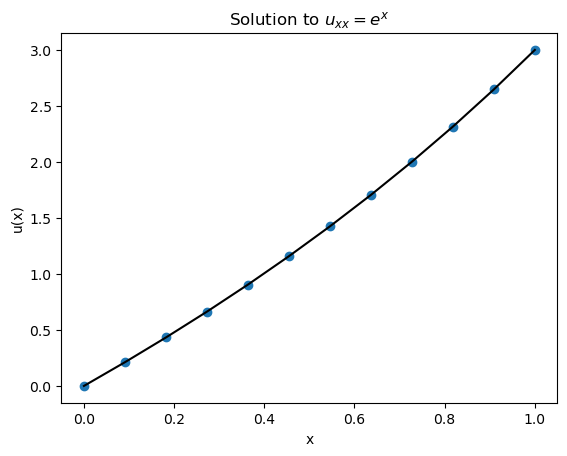

In [2]:
import numpy
import matplotlib.pyplot as plt

# Problem setup
a = 0.0
b = 1.0
u_a = 0.0
u_b = 3.0
f = lambda x: numpy.exp(x)
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x)

# Descretization
m = 10
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Construct matrix A
A = numpy.zeros((m, m))
diagonal = numpy.ones(m) / delta_x**2
A += numpy.diag(diagonal * -2.0, 0)
A += numpy.diag(diagonal[:-1], 1)
A += numpy.diag(diagonal[:-1], -1)

# Construct RHS
b = f(x)
b[0] -= u_a / delta_x**2
b[-1] -= u_b / delta_x**2

# Solve system
U = numpy.empty(m + 2)
U[0] = u_a
U[-1] = u_b
U[1:-1] = numpy.linalg.solve(A, b)

# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solution to $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

## Analisis Error

$U_i$ seberapa dekat nilai tersebut dengan solusi sebenarnya $u(x)$ pada titik-titik grid $x_i$.  

Untuk membahas hal ini, kita mendefinisikan **error** $E$ sebagai

$$
E = U - \widehat{U}
$$

di mana:
- $U$ adalah **vektor solusi pendekatan (aproksimasi)**,
- $\widehat{U}$ adalah **vektor yang berisi nilai solusi sebenarnya pada titik-titik grid**.

Vektor $\widehat{U}$ dibentuk dari nilai $u(x_i)$ sehingga

$$
\widehat{U_i} = u(x_i).
$$

Hal ini membuat $E$ masih berbentuk **vektor**, sehingga kita sering mengajukan pertanyaan: bagaimana perilaku norma dari $E$ untuk suatu nilai $\Delta x$ tertentu.

Untuk **norma tak hingga ($\infty$-norm)**, kita memiliki

$$
||E||_\infty = \max_{1 \leq i \leq m} |E_i|
= \max_{1 \leq i \leq m} |U_i - u(x_i)|
$$

Jika kita dapat menunjukkan bahwa $||E||_\infty$ menuju nol ketika $\Delta x \rightarrow 0$, maka kita dapat menyatakan bahwa solusi pendekatan $U_i$ pada setiap titik grid akan memenuhi $E_i \rightarrow 0$.

Jika kita ingin menggunakan norma lain, biasanya kita mendefinisikan versi norma yang sedikit dimodifikasi yang juga melibatkan lebar grid $\Delta x$, yaitu

$$
\begin{aligned}
||E||_1 &= \Delta x \sum_{i=1}^{m} |E_i| \\
||E||_2 &= \left( \Delta x \sum_{i=1}^{m} |E_i|^2 \right)^{1/2}
\end{aligned}
$$

Norma-norma ini disebut sebagai *grid function norms*.

Error $E$ yang didefinisikan di atas dikenal sebagai *global error*.  
Salah satu tujuan utama dalam mata kuliah ini adalah memahami bagaimana perilaku $E$ ketika dipengaruhi oleh berbagai faktor lain yang akan kita definisikan kemudian.

### Error Pemotongan Lokal (Local Truncation Error)

*Local truncation error* (LTE) dapat didefinisikan dengan mengganti solusi pendekatan $U_i$ dengan solusi sebenarnya $u(x_i)$.

Karena persamaan aljabar yang kita gunakan merupakan pendekatan dari masalah nilai batas (BVP) yang asli

Selisih yang muncul dari ketidaktepatan ini disebut sebagai **local truncation error (LTE)**.

Untuk pendekatan **finite difference satu dimensi** yang telah kita bahas sebelumnya, kita memiliki persamaan

$$
\frac{1}{\Delta x^2} (U_{i+1} - 2U_i + U_{i-1}) = f(x_i).
$$

Dengan mengganti $U_i$ dengan $u(x_i)$ pada persamaan tersebut, kita memperoleh

$$
\tau_i = \frac{1}{\Delta x^2}\left(u(x_{i+1}) - 2u(x_i) + u(x_{i-1})\right) - f(x_i).
$$

 jika kita mengasumsikan bahwa $u(x)$ adalah fungsi yang cukup halus (*smooth*), maka kita dapat mengganti $u(x_i)$ dengan bentuk deret Taylor-nya, mirip seperti yang kita lakukan pada pendekatan finite difference sebelumnya.

Deret Taylor yang relevan adalah

$$
u(x_{i \pm 1}) =
u(x_i)
\pm u'(x_i)\Delta x
+ \frac{1}{2}u''(x_i)\Delta x^2
\pm \frac{1}{6}u'''(x_i)\Delta x^3
+ \frac{1}{24}u^{(4)}(x_i)\Delta x^4
+ \mathcal{O}(\Delta x^5).
$$

Hal ini menghasilkan ekspresi untuk $\tau_i$ sebagai

$$
\begin{aligned}
\tau_i &= \frac{1}{\Delta x^2} \left[ u''(x_i)\Delta x^2 + \frac{1}{12}u^{(4)}(x_i)\Delta x^4 + \mathcal{O}(\Delta x^5) \right] - f(x_i) \\

&= u''(x_i) + \frac{1}{12}u^{(4)}(x_i)\Delta x^2 + \mathcal{O}(\Delta x^4) - f(x_i) \\

&= \frac{1}{12}u^{(4)}(x_i)\Delta x^2 + \mathcal{O}(\Delta x^4)
\end{aligned}
$$

di mana kita perhatikan bahwa solusi sebenarnya memenuhi

$$
u''(x) = f(x).
$$

Selama $u^{(4)}(x_i)$ tetap berhingga (fungsi cukup halus atau *smooth*), maka kita mengetahui bahwa

$$
\tau_i \rightarrow 0 \quad \text{ketika} \quad \Delta x \rightarrow 0.
$$

Kita juga dapat menuliskan **vektor local truncation error (LTE)** sebagai

$$
\tau = A \widehat{U} - F
$$

yang menyiratkan bahwa

$$
A\widehat{U} = F + \tau.
$$

 di sini yang digunakan adalah **solusi eksak yang dievaluasi pada stencil**, bukan fungsi pendekatan.

### Global Error

Yang sebenarnya ingin kita batasi (analisis) adalah **global error** $E$.  
Untuk menghubungkan **global error** dengan **local truncation error (LTE)**, kita dapat mensubstitusikan

$$
E = U - \widehat{U}
$$

ke dalam ekspresi LTE, sehingga diperoleh

$$
A E = -\tau.
$$

Hal ini berarti bahwa **global error** merupakan solusi dari sistem persamaan yang sama seperti sistem yang kita gunakan untuk mencari solusi pendekatan, tetapi dengan $\tau$ sebagai **fungsi pemaksa (forcing function)**, bukan $F$.

Hal ini juga menyiratkan bahwa **global error** $E$ dapat dipandang sebagai pendekatan terhadap masalah nilai batas (BVP) yang serupa dengan yang kita mulai, yaitu

$$
e''(x) = -\tau(x), \quad \Omega = [0,1]
$$

dengan kondisi batas

$$
e(0) = 0, \quad e(1) = 0.
$$

Persamaan diferensial ini dapat kita selesaikan secara langsung dengan melakukan integrasi dua kali untuk memperoleh orde utama (leading order)

$$
\begin{aligned}
e(x) &\approx -\frac{1}{12}\Delta x^2 u''(x)
+ \frac{1}{12}\Delta x^2 \left(u''(0) + x\,(u''(1) - u''(0))\right) \\

&= \mathcal{O}(\Delta x^2) \rightarrow 0 
\quad \text{ketika} \quad \Delta x \rightarrow 0.
\end{aligned}
$$

### Stabilitas

Kita telah menunjukkan bahwa analog kontinu dari $E$, yaitu $e(x)$, memang menuju nol ketika $\Delta x \rightarrow 0$.

 kembali melihat sistem persamaan awal untuk **global error**:

$$
A_{\Delta x} E_{\Delta x} = -\tau_{\Delta x}
$$

di mana sekarang kita menyatakan suatu realisasi tertentu dari sistem dengan **jarak grid yang bersesuaian**, yaitu $\Delta x$.

Jika kita dapat membalik (menghitung invers) dari $A_{\Delta x}$, maka kita dapat menghitung $E_{\Delta x}$ secara langsung. Dengan mengasumsikan bahwa hal ini dapat dilakukan dan dengan mengambil norma yang sesuai, kita memperoleh

$$
\begin{aligned}
E_{\Delta x} &= (A_{\Delta x})^{-1} \tau_{\Delta x} \\

||E_{\Delta x}|| &= ||(A_{\Delta x})^{-1} \tau_{\Delta x}|| \\

&\leq ||(A_{\Delta x})^{-1}|| \, ||\tau_{\Delta x}||
\end{aligned}
$$

Kita sudah mengetahui bahwa $\tau_{\Delta x} \rightarrow 0$ ketika $\Delta x \rightarrow 0$ pada contoh kita. Oleh karena itu, jika kita dapat membatasi norma matriks $(A_{\Delta x})^{-1}$ dengan suatu konstanta $C$ untuk $\Delta x$ yang cukup kecil, maka kita dapat menuliskan batas untuk **global error** sebagai

$$
||E_{\Delta x}|| \leq C ||\tau_{\Delta x}||
$$

yang menunjukkan bahwa

$$
E_{\Delta x} \rightarrow 0
$$

setidaknya **secepat** $\tau_{\Delta x} \rightarrow 0$.

Kita dapat menggeneralisasi pengamatan ini untuk semua masalah nilai batas (BVP) linear dengan mengasumsikan bahwa kita memiliki pendekatan finite difference terhadap suatu BVP linear dalam bentuk

$$
A_{\Delta x} U_{\Delta x} = F_{\Delta x},
$$

di mana $\Delta x$ adalah jarak antar titik grid (*grid spacing*).

Kita mengatakan bahwa pendekatan tersebut **stabil (stable)** jika $(A_{\Delta x})^{-1}$ ada untuk setiap $\Delta x < \Delta x_0$, dan terdapat suatu konstanta $C$ sehingga

$$
||(A_{\Delta x})^{-1}|| \leq C 
\quad \forall \Delta x < \Delta x_0.
$$

### Konsistensi (Consistency)

Salah satu konsep penting yang berkaitan dengan diskretisasi setiap persamaan diferensial parsial (PDE) adalah bahwa metode tersebut harus **konsisten** dengan persamaan yang kita aproksimasi.

Jika

$$
||\tau_{\Delta x}|| \rightarrow 0 
\quad \text{ketika} \quad 
\Delta x \rightarrow 0
$$

maka kita mengatakan bahwa pendekatan tersebut **konsisten (consistent)** dengan persamaan diferensialnya.

### Konvergensi (Convergence)

Sekarang kita telah memiliki semua komponen untuk menyatakan sesuatu tentang **global error** $E$.  
Suatu metode dikatakan **konvergen (convergent)** jika

$$
||E_{\Delta x}|| \rightarrow 0 
\quad \text{ketika} \quad 
\Delta x \rightarrow 0.
$$

Jika suatu pendekatan bersifat **konsisten** 
($||\tau_{\Delta x}|| \rightarrow 0$ ketika $\Delta x \rightarrow 0$) 
dan **stabil** 
($||E_{\Delta x}|| \leq C ||\tau_{\Delta x}||$), 
maka pendekatan tersebut **konvergen**.

Kita hanya menurunkan hasil ini untuk kasus **BVP linear**, tetapi pada kenyataannya kriteria konvergensi ini sering juga berlaku untuk hampir semua pendekatan **finite difference** (bahkan untuk metode lain juga).

Pernyataan tentang konvergensi ini sering dapat diperkuat menjadi

$$
\mathcal{O}(\Delta x^p) \text{ LTE } + \text{ stability } 
\Rightarrow 
\mathcal{O}(\Delta x^p) \text{ global error}.
$$